# Softmax exercise

*Complete and hand in this completed worksheet (including its outputs and any supporting code outside of the worksheet) with your assignment submission. For more details see the [assignments page](http://vision.stanford.edu/teaching/cs231n/assignments.html) on the course website.*

This exercise is analogous to the SVM exercise. You will:

- implement a fully-vectorized **loss function** for the Softmax classifier
- implement the fully-vectorized expression for its **analytic gradient**
- **check your implementation** with numerical gradient
- use a validation set to **tune the learning rate and regularization** strength
- **optimize** the loss function with **SGD**
- **visualize** the final learned weights


In [1]:
import random
import numpy as np
from cs231n.data_utils import load_CIFAR10
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading extenrnal modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2

In [3]:
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000, num_dev=500):
    """
    Load the CIFAR-10 dataset from disk and perform preprocessing to prepare
    it for the linear classifier. These are the same steps as we used for the
    SVM, but condensed to a single function.  
    """
    # Load the raw CIFAR-10 data
    cifar10_dir = 'cs231n/cifar-10-batches-py'
    
    # Cleaning up variables to prevent loading data multiple times (which may cause memory issue)
    try:
       del X_train, y_train
       del X_test, y_test
       print('Clear previously loaded data.')
    except:
       pass

    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
    
    # subsample the data
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]
    mask = np.random.choice(num_training, num_dev, replace=False)
    X_dev = X_train[mask]
    y_dev = y_train[mask]
    
    # Preprocessing: reshape the image data into rows
    X_train = np.reshape(X_train, (X_train.shape[0], -1))
    X_val = np.reshape(X_val, (X_val.shape[0], -1))
    X_test = np.reshape(X_test, (X_test.shape[0], -1))
    X_dev = np.reshape(X_dev, (X_dev.shape[0], -1))
    
    # Normalize the data: subtract the mean image
    mean_image = np.mean(X_train, axis = 0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image
    X_dev -= mean_image
    
    # add bias dimension and transform into columns
    X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
    X_val = np.hstack([X_val, np.ones((X_val.shape[0], 1))])
    X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
    X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])
    
    return X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev


# Invoke the above function to get our data.
X_train, y_train, X_val, y_val, X_test, y_test, X_dev, y_dev = get_CIFAR10_data()
print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Validation data shape: ', X_val.shape)
print('Validation labels shape: ', y_val.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)
print('dev data shape: ', X_dev.shape)
print('dev labels shape: ', y_dev.shape)

Train data shape:  (49000, 3073)
Train labels shape:  (49000,)
Validation data shape:  (1000, 3073)
Validation labels shape:  (1000,)
Test data shape:  (1000, 3073)
Test labels shape:  (1000,)
dev data shape:  (500, 3073)
dev labels shape:  (500,)


## Softmax Classifier

Your code for this section will all be written inside **cs231n/classifiers/softmax.py**. 


In [4]:
# First implement the naive softmax loss function with nested loops.
# Open the file cs231n/classifiers/softmax.py and implement the
# softmax_loss_naive function.

from cs231n.classifiers.softmax import softmax_loss_naive
import time

# Generate a random softmax weight matrix and use it to compute the loss.
W = np.random.randn(3073, 10) * 0.0001
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As a rough sanity check, our loss should be something close to -log(0.1).
print('loss: %f' % loss)
print('sanity check: %f' % (-np.log(0.1)))

loss: 2.432462
sanity check: 2.302585


**Inline Question 1**

Why do we expect our loss to be close to -log(0.1)? Explain briefly.**

$\color{blue}{\textit Your Answer:}$ 

在权重矩阵$W$随机初始化时，每个类别的得分大致相等。对于10个类别的分类问题，如果模型对所有类别的预测概率相等，则每个类别的概率为$\frac{1}{10} = 0.1$。

Softmax损失函数是交叉熵损失：$L_i = -\log(p_{y_i})$，其中$p_{y_i}$是正确类别的预测概率。

如果正确类别的概率$p_{y_i} = 0.1$，则损失为：
$$L_i = -\log(0.1) = -\log(10^{-1}) = \log(10) \approx 2.3026$$

由于所有样本的损失都接近$-\log(0.1)$，平均损失也接近$-\log(0.1)$。

**为什么概率是0.1？** 在随机初始化时，权重$W$的值很小且随机，导致所有类别的得分$s_j = X_i \cdot W_j$都接近0。经过softmax归一化后，所有类别的概率都接近$\frac{1}{C} = \frac{1}{10} = 0.1$（均匀分布）。 



In [5]:
# Complete the implementation of softmax_loss_naive and implement a (naive)
# version of the gradient that uses nested loops.
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 0.0)

# As we did for the SVM, use numeric gradient checking as a debugging tool.
# The numeric gradient should be close to the analytic gradient.
from cs231n.gradient_check import grad_check_sparse
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 0.0)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

# similar to SVM case, do another gradient check with regularization
loss, grad = softmax_loss_naive(W, X_dev, y_dev, 5e1)
f = lambda w: softmax_loss_naive(w, X_dev, y_dev, 5e1)[0]
grad_numerical = grad_check_sparse(f, W, grad, 10)

numerical: -0.131267 analytic: -0.131267, relative error: 1.161462e-07
numerical: 1.324094 analytic: 1.324094, relative error: 5.625781e-11
numerical: 2.088487 analytic: 2.088487, relative error: 5.071730e-10
numerical: 1.310019 analytic: 1.310019, relative error: 1.705595e-08
numerical: -1.604601 analytic: -1.604601, relative error: 7.393439e-09
numerical: -0.544373 analytic: -0.544373, relative error: 7.758730e-09
numerical: -0.487064 analytic: -0.487064, relative error: 1.193785e-07
numerical: 0.104558 analytic: 0.104558, relative error: 1.738262e-07
numerical: 2.382148 analytic: 2.382148, relative error: 9.137839e-09
numerical: -3.792044 analytic: -3.792044, relative error: 1.820474e-08
numerical: 2.203041 analytic: 2.203041, relative error: 9.170753e-10
numerical: -1.425058 analytic: -1.425058, relative error: 4.020356e-09
numerical: 0.701455 analytic: 0.701454, relative error: 9.486286e-08
numerical: -1.868765 analytic: -1.868765, relative error: 4.750141e-09
numerical: 1.931237 

In [6]:
# Now that we have a naive implementation of the softmax loss function and its gradient,
# implement a vectorized version in softmax_loss_vectorized.
# The two versions should compute the same results, but the vectorized version should be
# much faster.
tic = time.time()
loss_naive, grad_naive = softmax_loss_naive(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('naive loss: %e computed in %fs' % (loss_naive, toc - tic))

from cs231n.classifiers.softmax import softmax_loss_vectorized
tic = time.time()
loss_vectorized, grad_vectorized = softmax_loss_vectorized(W, X_dev, y_dev, 0.000005)
toc = time.time()
print('vectorized loss: %e computed in %fs' % (loss_vectorized, toc - tic))

# As we did for the SVM, we use the Frobenius norm to compare the two versions
# of the gradient.
grad_difference = np.linalg.norm(grad_naive - grad_vectorized, ord='fro')
print('Loss difference: %f' % np.abs(loss_naive - loss_vectorized))
print('Gradient difference: %f' % grad_difference)

naive loss: 2.432462e+00 computed in 0.045180s
vectorized loss: 2.432462e+00 computed in 0.002555s
Loss difference: 0.000000
Gradient difference: 0.000000


In [9]:
# Use the validation set to tune hyperparameters (regularization strength and
# learning rate). You should experiment with different ranges for the learning
# rates and regularization strengths; if you are careful you should be able to
# get a classification accuracy of over 0.35 on the validation set.
from cs231n.classifiers import Softmax
results = {}
best_val = -1
best_softmax = None
learning_rates = [1e-7, 5e-7]
regularization_strengths = [2.5e4, 5e4]

################################################################################
# TODO:                                                                        #
# Use the validation set to set the learning rate and regularization strength. #
# This should be identical to the validation that you did for the SVM; save    #
# the best trained softmax classifer in best_softmax.                          #
################################################################################
# *****START OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****

for lr in learning_rates:
    for reg in regularization_strengths:
        # 训练Softmax
        softmax = Softmax()
        loss_hist = softmax.train(X_train, y_train, learning_rate=lr, reg=reg,
                                  num_iters=1500, verbose=False)
        
        # 预测
        y_train_pred = softmax.predict(X_train)
        y_val_pred = softmax.predict(X_val)
        
        # 计算准确率
        train_acc = np.mean(y_train_pred == y_train)
        val_acc = np.mean(y_val_pred == y_val)
        
        # 保存结果
        results[(lr, reg)] = (train_acc, val_acc)
        
        # 更新最佳模型
        if val_acc > best_val:
            best_val = val_acc
            best_softmax = softmax

# *****END OF YOUR CODE (DO NOT DELETE/MODIFY THIS LINE)*****
    
# Print out results.
for lr, reg in sorted(results):
    train_accuracy, val_accuracy = results[(lr, reg)]
    print('lr %e reg %e train accuracy: %f val accuracy: %f' % (
                lr, reg, train_accuracy, val_accuracy))
    
print('best validation accuracy achieved during cross-validation: %f' % best_val)

lr 1.000000e-07 reg 2.500000e+04 train accuracy: 0.329306 val accuracy: 0.340000
lr 1.000000e-07 reg 5.000000e+04 train accuracy: 0.308878 val accuracy: 0.325000
lr 5.000000e-07 reg 2.500000e+04 train accuracy: 0.326878 val accuracy: 0.337000
lr 5.000000e-07 reg 5.000000e+04 train accuracy: 0.304388 val accuracy: 0.325000
best validation accuracy achieved during cross-validation: 0.340000


In [10]:
# evaluate on test set
# Evaluate the best softmax on test set
y_test_pred = best_softmax.predict(X_test)
test_accuracy = np.mean(y_test == y_test_pred)
print('softmax on raw pixels final test set accuracy: %f' % (test_accuracy, ))

softmax on raw pixels final test set accuracy: 0.338000


**Inline Question 2** - *True or False*

Suppose the overall training loss is defined as the sum of the per-datapoint loss over all training examples. It is possible to add a new datapoint to a training set that would leave the SVM loss unchanged, but this is not the case with the Softmax classifier loss.

$\color{blue}{\textit Your Answer:}$ **True**

$\color{blue}{\textit Your Explanation:}$

**SVM损失函数**：$L_i = \sum_{j \neq y_i} \max(0, s_j - s_{y_i} + 1)$

如果新数据点的所有错误类别的margin都≤0（即$s_j - s_{y_i} + 1 \leq 0$对所有$j \neq y_i$），则$\max(0, ...) = 0$，该样本的损失为0，**不会改变总损失**。

**例子**：假设新样本的正确类别得分$s_{y_i} = 10$，所有错误类别的得分$s_j \leq 9$，则margin = $s_j - 10 + 1 \leq 0$，损失为0。

**Softmax损失函数**：$L_i = -\log(p_{y_i})$，其中$p_{y_i} = \frac{e^{s_{y_i}}}{\sum_j e^{s_j}}$

由于softmax概率归一化（所有概率和为1），**任何新数据点都会改变概率分布**，从而改变损失。即使新样本的预测概率很高（接近1），$-\log(p_{y_i})$仍然是一个正数（虽然很小），**总损失一定会增加**。

**关键区别**：
- **SVM**：如果margin ≤ 0，损失为0，可以"忽略"某些样本
- **Softmax**：所有样本都产生损失（$-\log(p) > 0$，因为$p < 1$），无法"忽略"任何样本

因此，**SVM可以添加不改变损失的样本，但Softmax不能**。



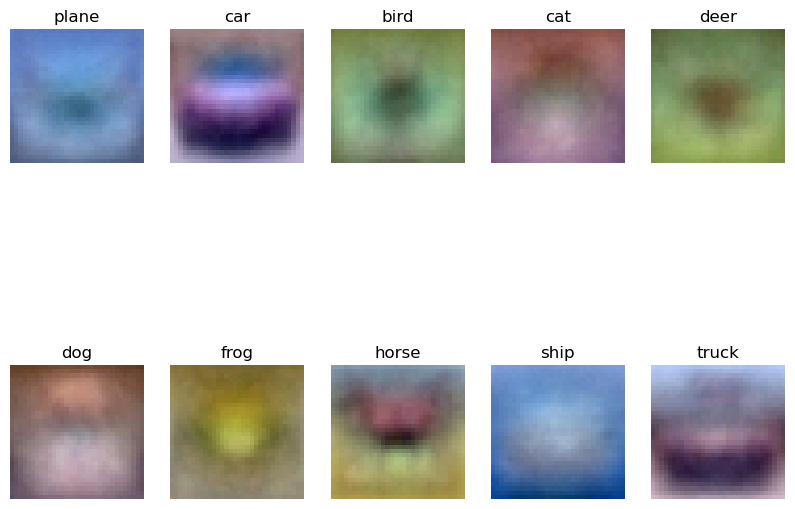

In [11]:
# Visualize the learned weights for each class
w = best_softmax.W[:-1,:] # strip out the bias
w = w.reshape(32, 32, 3, 10)

w_min, w_max = np.min(w), np.max(w)

classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    plt.subplot(2, 5, i + 1)
    
    # Rescale the weights to be between 0 and 255
    wimg = 255.0 * (w[:, :, :, i].squeeze() - w_min) / (w_max - w_min)
    plt.imshow(wimg.astype('uint8'))
    plt.axis('off')
    plt.title(classes[i])